# Generative models: Adult census income dataset

**ML-MDS 2026 - Elisa Muller and Berta Torrents**

## 0. Introduction

This notebook trains and evaluates a family of generative classifiers on the Adult census income dataset. All models are evaluated under the same cross-validation protocol on the training partition produced by the preprocessing notebook, and the test partition is held out until the final evaluation.

Unlike discriminative models such as Logistic Regression, generative classifiers explicitly model the distribution of the features within each class and apply Bayes' rule to predict. This makes the choice of distributional family a core modelling decision, not just a technical detail.

Three model families are covered: LDA and QDA, which model the class-conditional densities as multivariate Gaussians, and Naive Bayes, which adds the conditional independence assumption and allows different distributional families per feature block.

## 1. Setup and data loading

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import BernoulliNB, GaussianNB

SEED = 42
np.random.seed(SEED)

PLOT_COLORS = {
    "neutral": "#FA8FB1",
    "neutral_light": "#7DB7FF",
    "income_low": "#2F80ED",
    "income_high": "#FF8A00",
    "before": "#7B8794",
    "after": "#00B894",
    "outlier": "#E63946",
    "reference": "#4A5568",
}
TARGET_PALETTE = {0: PLOT_COLORS["income_low"], 1: PLOT_COLORS["income_high"]}
MODEL_PALETTE = {
    "Baseline": "#8C8C8C",
    "LDA": "#74DA00",
    "QDA": "#015F04",
    "GaussianNB": "#AC1769",
    "BernoulliNB": "#DC6DAF",
    "CombinedNB": "#B62DCE",
}

sns.set_theme(
    style="whitegrid",
    palette=list(PLOT_COLORS.values()),
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.edgecolor": "#D7DEE8",
        "axes.linewidth": 0.8,
        "grid.color": "#E8EDF3",
        "grid.linewidth": 0.7,
        "legend.frameon": False,
    },
)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.titlepad"] = 10


def polish_axes(ax, grid_axis="y"):
    ax.grid(False)
    ax.grid(True, axis=grid_axis, alpha=0.55)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    return ax


warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
X_train = pd.read_csv("adult_X_train.csv", index_col=0)
X_test = pd.read_csv("adult_X_test.csv", index_col=0)
y_train = pd.read_csv("adult_y_train.csv", index_col=0).squeeze()
y_test = pd.read_csv("adult_y_test.csv", index_col=0).squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (26048, 73)
X_test:  (6513, 73)


In [3]:
continuous_features = [c for c in X_train.columns if c.startswith("num__")]
binary_features = [c for c in X_train.columns if c.startswith("bin__")]
onehot_features = [c for c in X_train.columns if c.startswith("cat__")]
binary_block = binary_features + onehot_features

print(f"Continuous: {len(continuous_features)} -> {continuous_features}")
print(f"Binary: {len(binary_features)} -> {binary_features}")
print(f"One-hot: {len(onehot_features)}")
print(f"Total: {X_train.shape[1]}")

Continuous: 7 -> ['num__age', 'num__education_num', 'num__hours_per_week', 'num__capital_gain_log', 'num__capital_loss_log', 'num__net_capital', 'num__age_x_hours']
Binary: 5 -> ['bin__sex', 'bin__capital_gain_is_99999', 'bin__has_capital_activity', 'bin__is_higher_education', 'bin__is_US']
One-hot: 61
Total: 73


## 2. Experimental setup

### 2.1 Cross-validation protocol

A single `StratifiedKFold` with five folds is instantiated once and reused throughout the notebook for both hyperparameter search and cross-family comparison. Stratification preserves the 76/24 class ratio in every fold.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### 2.2 Metrics

The target is imbalanced (24% positives). Accuracy is reported but not used for model selection because a constant majority predictor already reaches 76%. The primary selection metric is F1 on the positive class, which balances precision and recall on the minority class. ROC-AUC and AUPR are reported as supporting metrics: ROC-AUC measures ranking quality across all thresholds; AUPR focuses on the positive class and is more informative than ROC-AUC under imbalance.

In [5]:
SCORING = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "aupr": "average_precision",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
}

PRIMARY_METRIC = "f1"

results = []


def record_cv(name, scores):
    row = {"model": name}
    for metric in SCORING:
        key = f"test_{metric}"
        row[f"{metric}_mean"] = scores[key].mean()
        row[f"{metric}_std"] = scores[key].std()
    results.append(row)
    return row

### 2.3 Baseline

The `DummyClassifier` with `most_frequent` strategy always predicts the majority class. It is the absolute floor: any meaningful model must beat it. Its F1 on the positive class is zero since it never predicts it, which illustrates concretely why accuracy is a misleading metric here.

In [6]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_scores = cross_validate(dummy, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
record_cv("Baseline: Dummy (most_frequent)", dummy_scores)

pd.DataFrame(results).set_index("model").round(3)

,f1_mean,f1_std,roc_auc_mean,roc_auc_std,aupr_mean,aupr_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
model,,,,,,,,,,,,
Baseline: Dummy (most_frequent),0.0,0.0,0.5,0.0,0.241,0.0,0.759,0.0,0.0,0.0,0.0,0.0


## 3. Gaussian assumption check

LDA, QDA and Gaussian NB all assume that the features follow a multivariate Gaussian distribution within each class. The EDA already flagged potential issues: capital features are heavily zero-inflated even after the log transform and `education_num` is discrete and multimodal. This section formalizes that intuition and determines which features are viable candidates for these models. The one-hot and binary columns are excluded: they are Bernoulli by construction and are handled separately in the Naive Bayes section.

### 3.1 Visual check: distributions within each class

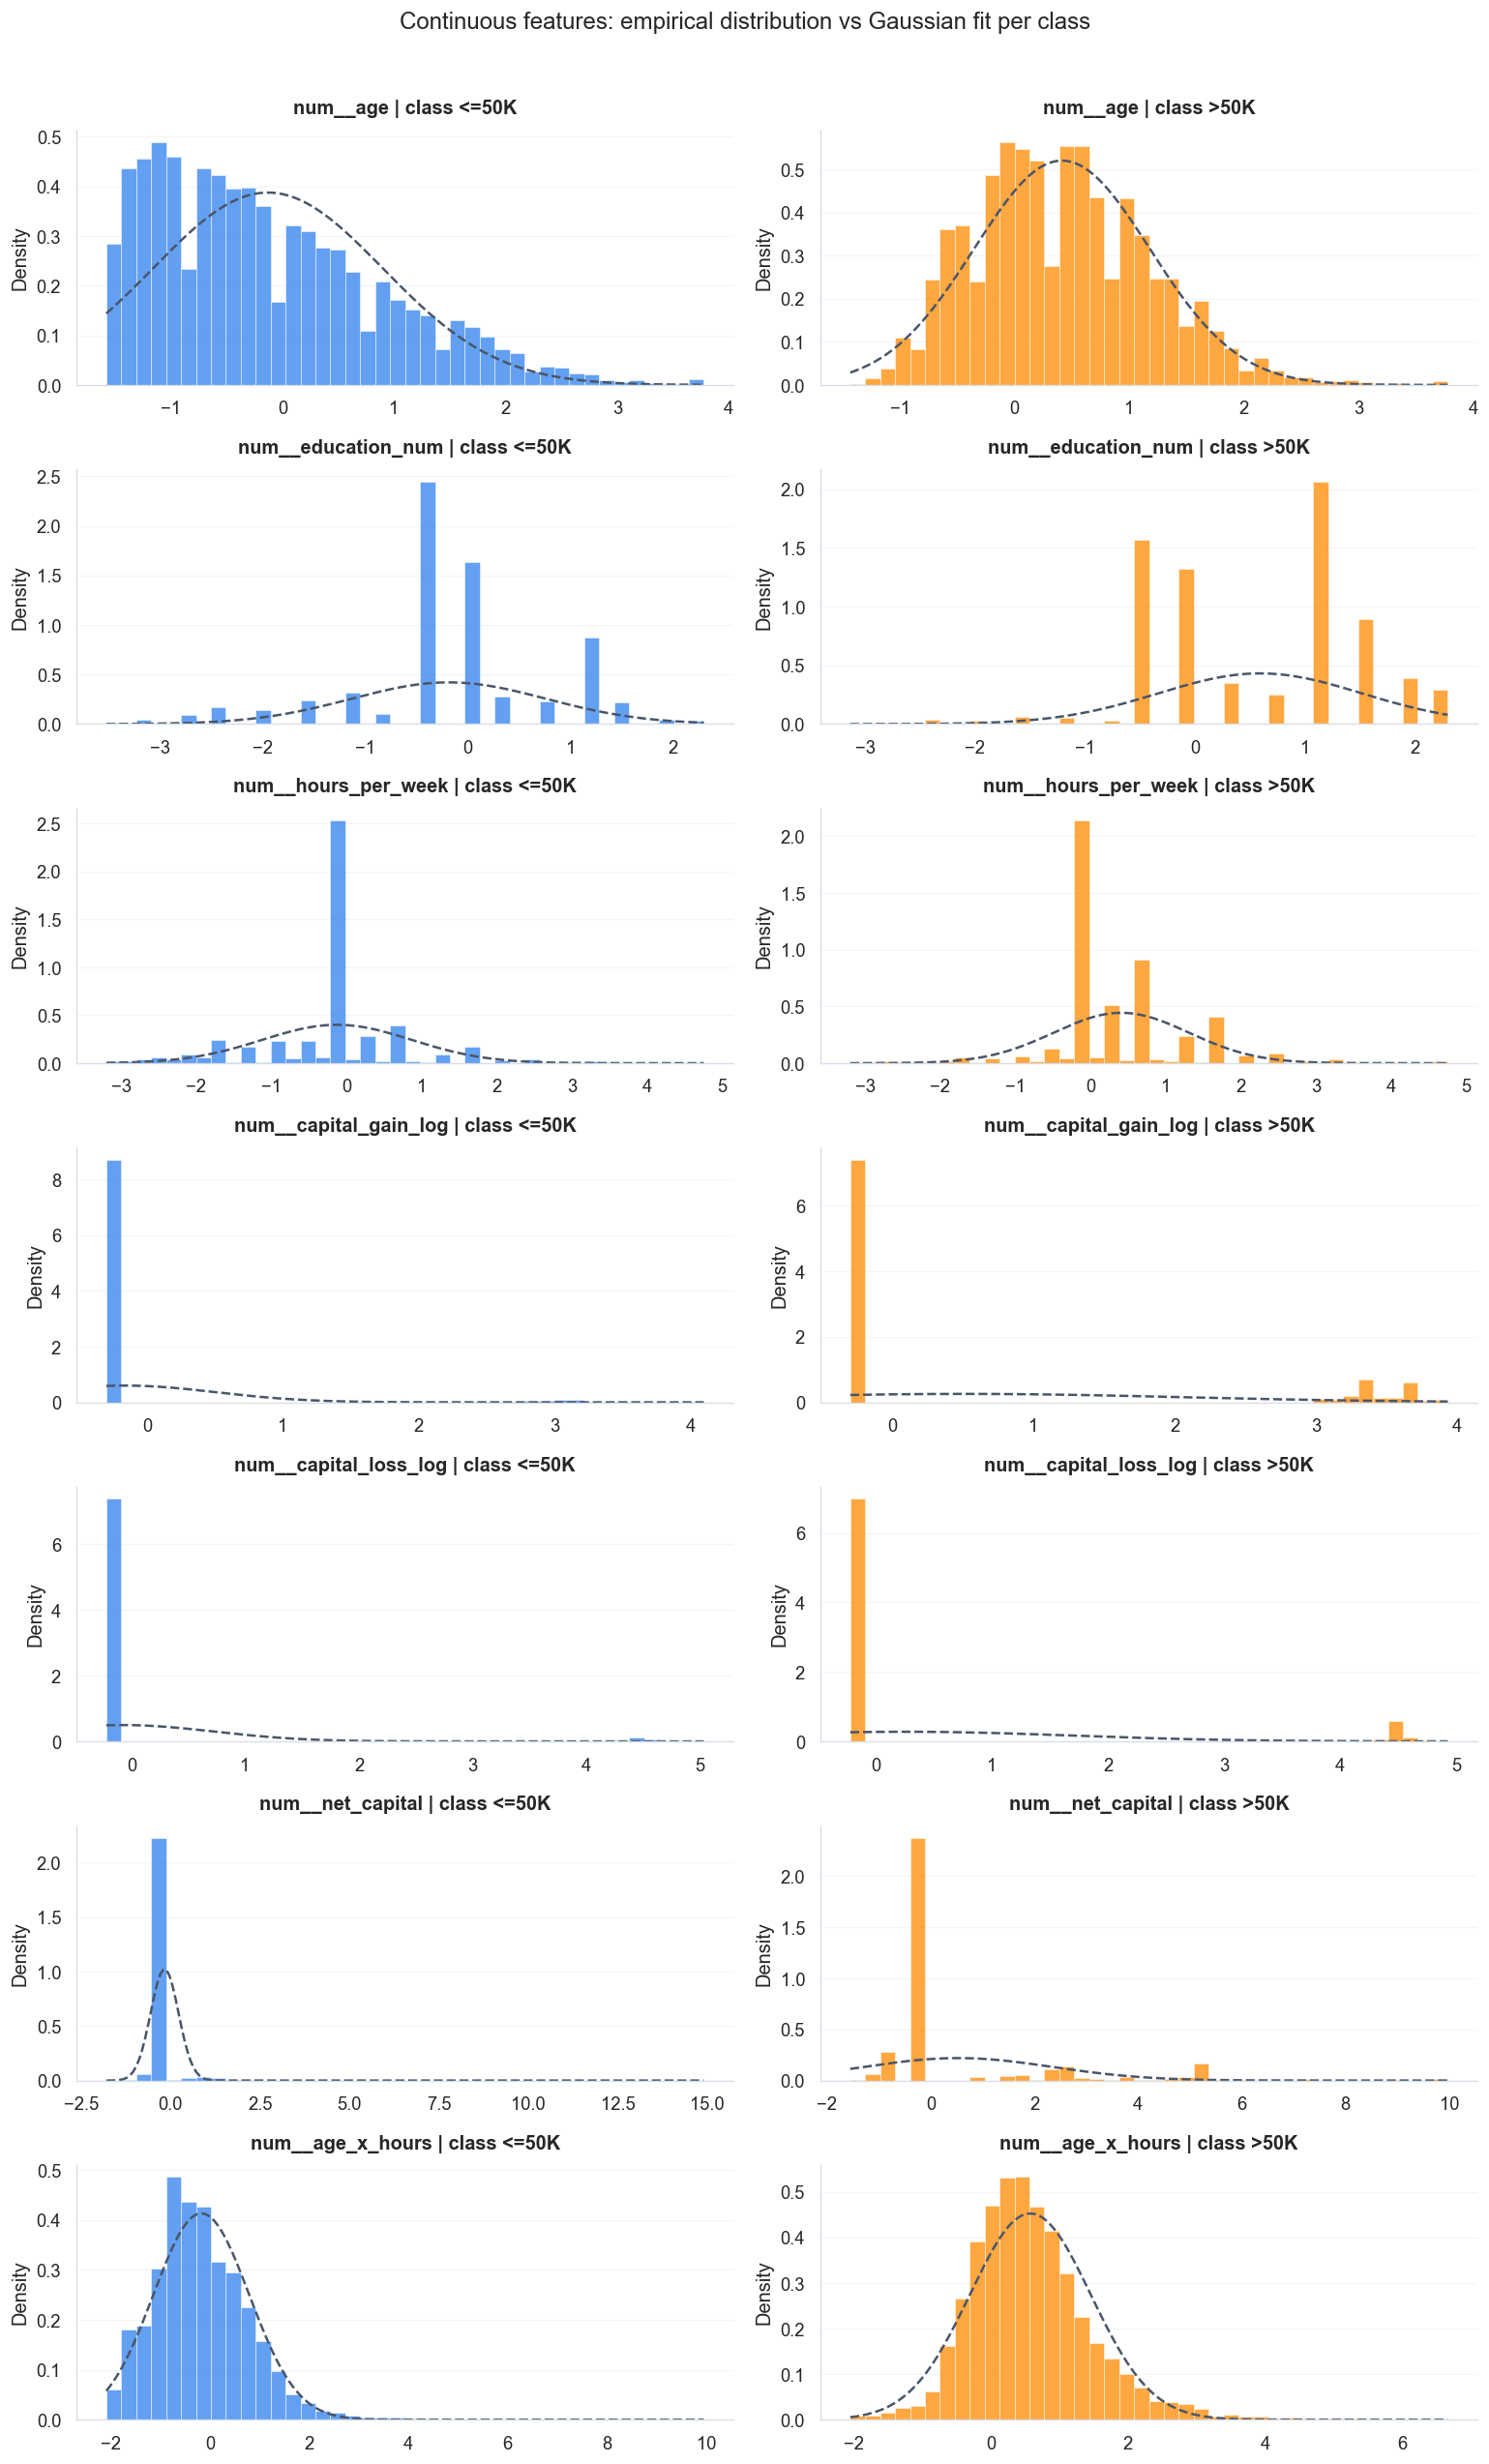

In [7]:
n_feats = len(continuous_features)
fig, axes = plt.subplots(n_feats, 2, figsize=(13, 3 * n_feats))

for i, feat in enumerate(continuous_features):
    for j, (label, color) in enumerate(TARGET_PALETTE.items()):
        ax = axes[i, j]
        data = X_train.loc[y_train == label, feat].dropna()
        ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="white", linewidth=0.4, density=True)
        mu, sigma = data.mean(), data.std()
        x_range = np.linspace(data.min(), data.max(), 200)
        ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
                color=PLOT_COLORS["reference"], linewidth=1.5, linestyle="--", label="Gaussian fit")
        ax.set_title(f"{feat} | class {'<=50K' if label == 0 else '>50K'}")
        ax.set_ylabel("Density")
        polish_axes(ax)

plt.suptitle("Continuous features: empirical distribution vs Gaussian fit per class", y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Shapiro-Wilk normality test per feature and class

The Shapiro-Wilk test provides a formal normality check. All p-values are 0, meaning normality is rejected for every feature and class. This is expected at this sample size: with thousands of observations, even tiny deviations from Gaussianity become statistically significant. The plots above are therefore the more informative diagnostic.

In [8]:
normality_rows = []

for feat in continuous_features:
    for label in [0, 1]:
        data = X_train.loc[y_train == label, feat].dropna()
        sample = data.sample(min(3000, len(data)), random_state=SEED)
        stat, pval = stats.shapiro(sample)
        normality_rows.append({
            "feature": feat,
            "class": "<=50K" if label == 0 else ">50K",
            "p_value": round(pval, 4),
            "reject_H0": pval < 0.05,
        })

normality_df = pd.DataFrame(normality_rows)
print(normality_df.to_string(index=False))

              feature class  p_value  reject_H0
             num__age <=50K      0.0       True
             num__age  >50K      0.0       True
   num__education_num <=50K      0.0       True
   num__education_num  >50K      0.0       True
  num__hours_per_week <=50K      0.0       True
  num__hours_per_week  >50K      0.0       True
num__capital_gain_log <=50K      0.0       True
num__capital_gain_log  >50K      0.0       True
num__capital_loss_log <=50K      0.0       True
num__capital_loss_log  >50K      0.0       True
     num__net_capital <=50K      0.0       True
     num__net_capital  >50K      0.0       True
     num__age_x_hours <=50K      0.0       True
     num__age_x_hours  >50K      0.0       True


The plots reveal clear violations for most features. `capital_gain_log`, `capital_loss_log` and `net_capital` are heavily zero-inflated in both classes: the vast majority of samples pile up at zero, which no Gaussian fit can capture. `education_num` shows a discrete multimodal distribution reflecting the ordinal nature of education levels. `hours_per_week` has a sharp spike at 40 hours that the Gaussian fit misses entirely.

The least severe violations are `age` and `age_x_hours`, which are roughly unimodal and bell-shaped. The practical implication is that LDA and QDA operate under a misspecified likelihood for most features, but the degree of misspecification varies. This does not prevent the models from producing useful predictions; the regularization parameters explored in the next section help absorb part of this misspecification.

## 4. LDA, QDA and RDA

LDA and QDA are both special cases of Regularized Discriminant Analysis (RDA), introduced by Friedman (1989). RDA defines a family of classifiers parameterized by two values that control the covariance structure used in the Gaussian class-conditional densities:

$$\hat{\Sigma}_k(\alpha, \gamma) = (1 - \alpha) \left[ (1 - \gamma) \hat{\Sigma}_k + \gamma \frac{\text{tr}(\hat{\Sigma}_k)}{p} I \right] + \alpha \hat{\Sigma}$$

where $\hat{\Sigma}_k$ is the per-class covariance, $\hat{\Sigma}$ is the pooled covariance, and $p$ is the number of features. The two parameters recover the classical methods as special cases:

- $\alpha=0, \gamma=0$: standard LDA (shared covariance, no shrinkage)
- $\alpha=0, \gamma=1$: isotropic LDA (shared covariance, scaled identity)
- $\alpha=1, \gamma=0$: standard QDA (per-class covariance, no shrinkage)
- $\alpha=1, \gamma=1$: isotropic QDA (per-class covariance, scaled identity)

Since sklearn does not implement RDA as a single estimator, `LinearDiscriminantAnalysis` is used with a shrinkage sweep over $\gamma$ and `QuadraticDiscriminantAnalysis` with a reg_param sweep over $\alpha$. Including 0 and 1 in both grids covers the full RDA parameter space.

Both models are trained on the full feature matrix. The Gaussian misspecification on binary and one-hot columns is absorbed by the shrinkage and regularization parameters explored below.

### 4.1 LDA: shrinkage sweep

The $\gamma$ parameter is swept over $[0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]$ plus the Ledoit-Wolf automatic estimate (`auto`). At $\gamma=0$ this is standard LDA; at $\gamma=1$ the covariance matrix becomes a scaled identity, treating all features as independent with equal variance (isotropic LDA).

In [9]:
lda_param_grid = {
    "solver": ["eigen"],
    "shrinkage": [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0, "auto"],
}

lda_search = GridSearchCV(
    LinearDiscriminantAnalysis(),
    param_grid=lda_param_grid,
    scoring=PRIMARY_METRIC,
    cv=cv,
    n_jobs=-1,
    refit=True,
)
lda_search.fit(X_train, y_train)

print(f"Best F1 (CV): {lda_search.best_score_:.4f}")
print(f"Best params:  {lda_search.best_params_}")

Best F1 (CV): 0.6534
Best params:  {'shrinkage': 0.2, 'solver': 'eigen'}


c:\Users\berta.torrents\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
5 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\berta.torrents\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\berta.torrents\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  Fi

In [10]:
lda_cv_df = pd.DataFrame(lda_search.cv_results_)
lda_table = lda_cv_df[
    ["param_solver", "param_shrinkage", "mean_test_score", "std_test_score"]
].copy()
lda_table.columns = ["solver", "shrinkage", "F1_mean", "F1_std"]
lda_table.sort_values("F1_mean", ascending=False).round(4)

,solver,shrinkage,F1_mean,F1_std
2,eigen,0.2,0.6534,0.0083
4,eigen,0.5,0.6529,0.0060
3,eigen,0.3,0.6520,0.0070
5,eigen,0.7,0.6504,0.0046
1,eigen,0.1,0.6502,0.0076
8,eigen,auto,0.6487,0.0083
6,eigen,0.9,0.6419,0.0048
7,eigen,1.0,0.6248,0.0087
0,eigen,0.0,NaN,NaN


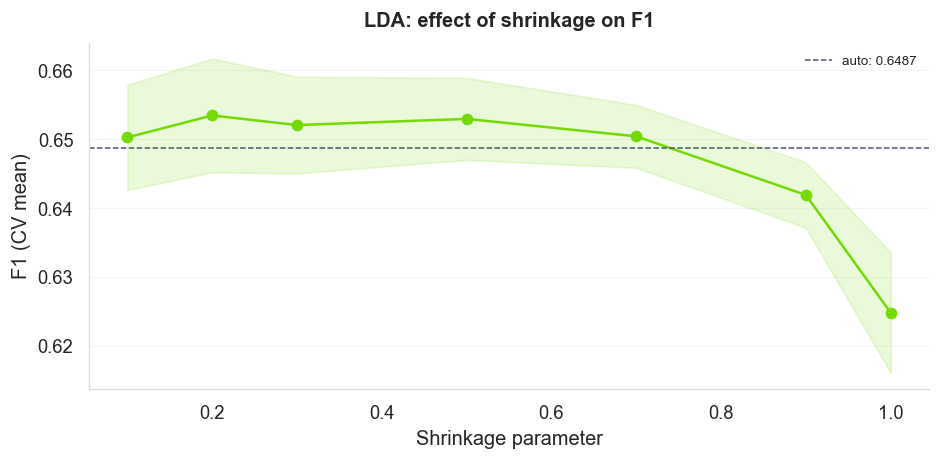

In [11]:
lda_best = lda_search.best_estimator_

loadings_ld1 = pd.Series(
    lda_best.coef_.ravel(),
    index=X_train.columns,
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))

subset = lda_table[
    lda_table["shrinkage"].apply(lambda x: isinstance(x, float))
].sort_values("shrinkage").copy()
subset["shrinkage"] = subset["shrinkage"].astype(float)

ax.plot(subset["shrinkage"], subset["F1_mean"], marker="o", color=MODEL_PALETTE["LDA"])
ax.fill_between(
    subset["shrinkage"],
    subset["F1_mean"] - subset["F1_std"],
    subset["F1_mean"] + subset["F1_std"],
    alpha=0.15,
    color=MODEL_PALETTE["LDA"],
)

auto_row = lda_table[lda_table["shrinkage"] == "auto"].iloc[0]
ax.axhline(auto_row["F1_mean"], linestyle="--", linewidth=0.9,
           color=PLOT_COLORS["reference"], label=f"auto: {auto_row['F1_mean']:.4f}")

ax.set_xlabel("Shrinkage parameter")
ax.set_ylabel("F1 (CV mean)")
ax.set_title("LDA: effect of shrinkage on F1")
ax.legend(fontsize=8)
polish_axes(ax)
plt.tight_layout()
plt.show()

The EDA showed that the continuous features have very low pairwise correlations, which
means the empirical covariance matrix is already close to diagonal. This explains why
mild shrinkage helps, since it stabilizes the estimates without forcing a structure that is
far from the truth. However, the one-hot columns do carry genuine class-specific
covariance patterns through their associations with income, so pushing shrinkage too high destroys that signal and hurts performance.
The reguralization parameter at 0.2 reflects this balance. The Ledoit-Wolf automatic estimate lands
at 0.649, well within the stable region and close to the optimum.

### 4.3 LDA: discriminant projection and feature importance

For a binary classification problem, LDA produces a single discriminant direction LD1: the linear combination of features that maximises the ratio of between-class variance to within-class variance. The LD1 coefficients act as a form of feature importance: features with large absolute loadings contribute most to the separation between classes, while features with near-zero loadings carry little discriminative information given the others.

For one-hot encoded variables, individual dummy columns cannot be evaluated in isolation since they jointly represent a single categorical variable. Dropping one column while keeping the others would break the encoding. The correct unit of analysis is therefore the variable group: the mean absolute LD1 loading across all dummies of a variable gives a single importance score that can be used to decide whether to keep or remove the entire variable.

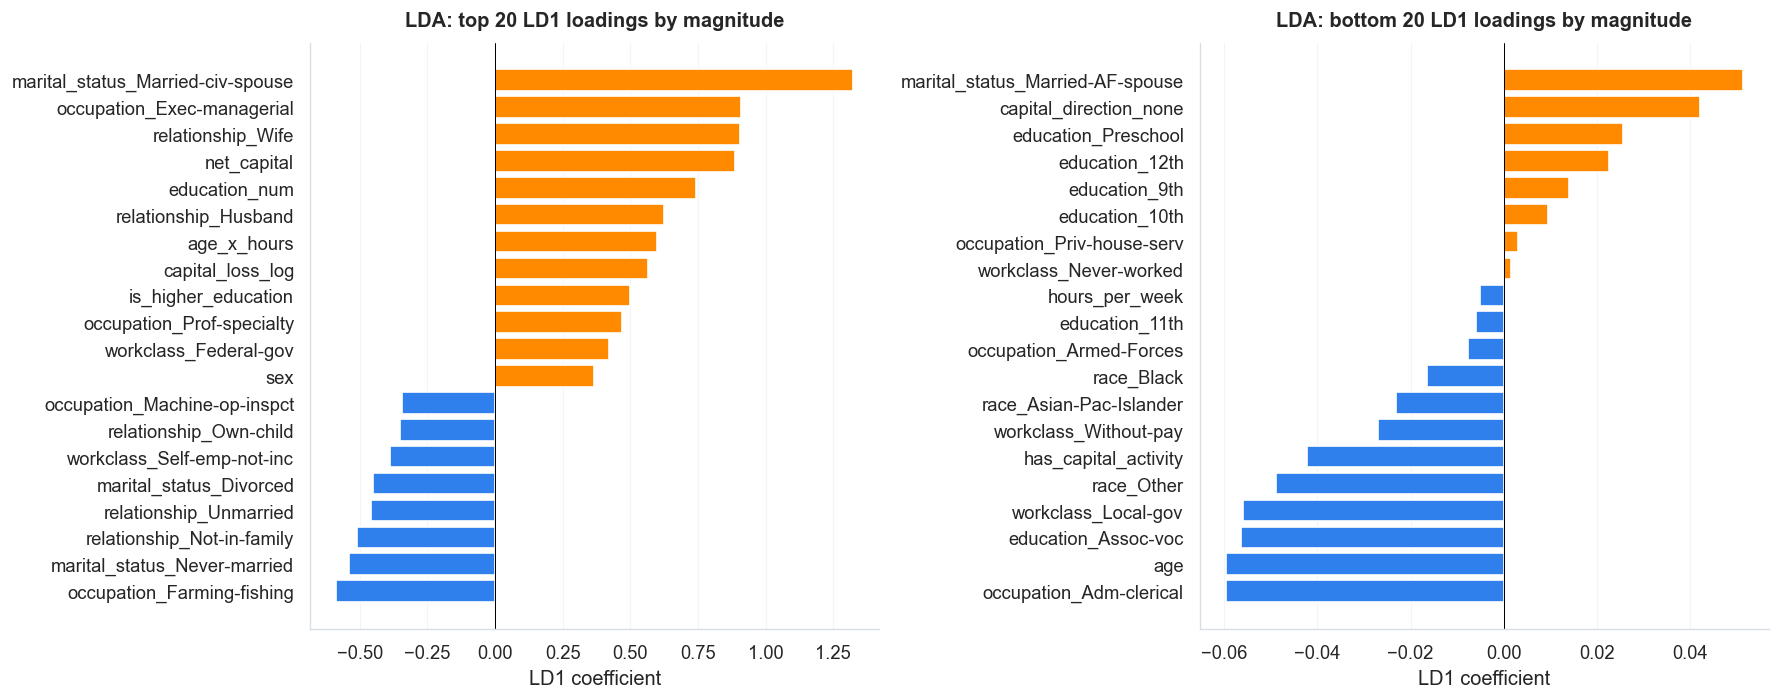

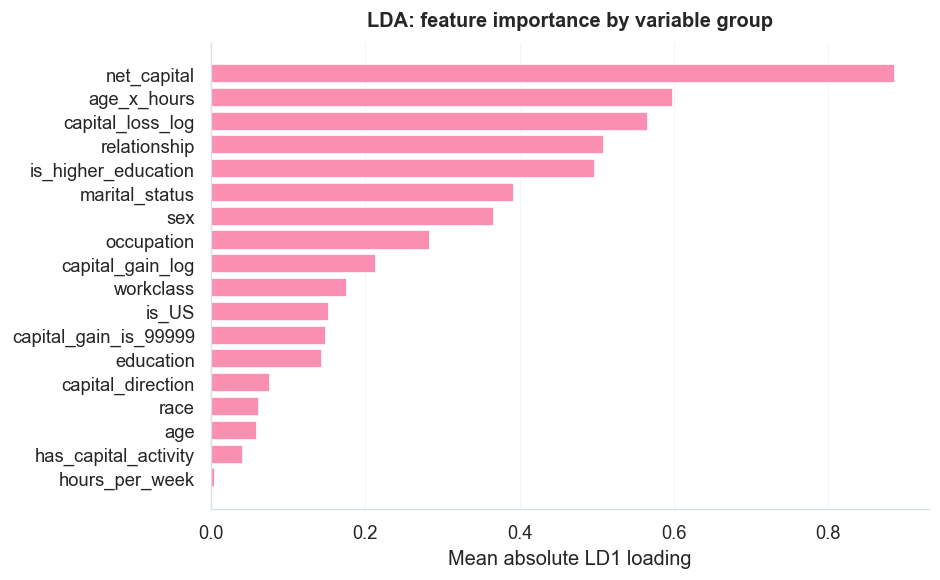

group
net_capital              0.8859
age_x_hours              0.5988
capital_loss_log         0.5661
relationship             0.5090
is_higher_education      0.4980
marital_status           0.3928
sex                      0.3665
occupation               0.2837
capital_gain_log         0.2141
workclass                0.1765
is_US                    0.1533
capital_gain_is_99999    0.1495
education                0.1446
capital_direction        0.0766
race                     0.0628
age                      0.0596
has_capital_activity     0.0421
hours_per_week           0.0050


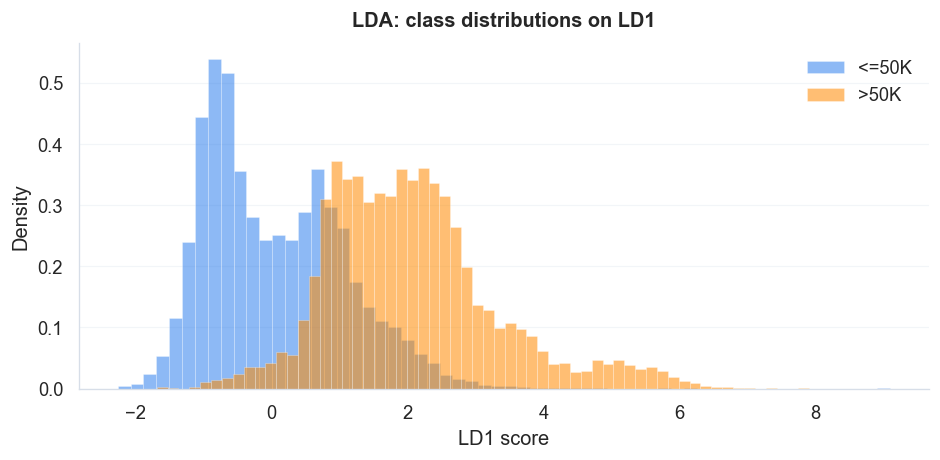

In [12]:
# Top and bottom individual loadings
top_n = 20
top_loadings = loadings_ld1.head(top_n).sort_values()
bottom_loadings = loadings_ld1.tail(top_n).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, data, title in [
    (axes[0], top_loadings, f"LDA: top {top_n} LD1 loadings by magnitude"),
    (axes[1], bottom_loadings, f"LDA: bottom {top_n} LD1 loadings by magnitude"),
]:
    colors = [
        PLOT_COLORS["income_high"] if v > 0 else PLOT_COLORS["income_low"]
        for v in data.values
    ]
    ax.barh(
        data.index.str.replace("num__", "").str.replace("bin__", "").str.replace("cat__", ""),
        data.values,
        color=colors,
    )
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel("LD1 coefficient")
    ax.set_title(title)
    polish_axes(ax, grid_axis="x")

plt.tight_layout()
plt.show()

# Group importance: mean absolute loading per variable group
def get_group(col):
    col = col.replace("num__", "").replace("bin__", "").replace("cat__", "")
    for var in ["marital_status", "occupation", "relationship", "workclass",
                "education", "race", "native_country", "capital_direction"]:
        if col.startswith(var):
            return var
    return col

loading_groups = pd.DataFrame({
    "feature": loadings_ld1.index,
    "loading": loadings_ld1.values,
    "group": loadings_ld1.index.map(get_group),
})

group_importance = (
    loading_groups.groupby("group")["loading"]
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    group_importance.index[::-1],
    group_importance.values[::-1],
    color=PLOT_COLORS["neutral"],
)
ax.set_xlabel("Mean absolute LD1 loading")
ax.set_title("LDA: feature importance by variable group")
polish_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

print(group_importance.round(4).to_string())

# Projected class distributions on LD1
X_ld1 = lda_best.transform(X_train).ravel()

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in TARGET_PALETTE.items():
    ax.hist(
        X_ld1[y_train == label],
        bins=60,
        alpha=0.55,
        color=color,
        density=True,
        label="<=50K" if label == 0 else ">50K",
        edgecolor="white",
        linewidth=0.3,
    )
ax.set_xlabel("LD1 score")
ax.set_ylabel("Density")
ax.set_title("LDA: class distributions on LD1")
ax.legend()
polish_axes(ax)
plt.tight_layout()
plt.show()

The top loadings are fully consistent with the EDA findings. Marital_status_Married-civ-spouse
is by far the strongest individual predictor, followed by executive and professional
occupations, relationship categories Wife and Husband, net_capital and education_num.
These all point toward the same demographic profile the EDA identified as most associated
with high income: married, educated, working in high-skill jobs with capital activity.
On the negative side, Farming-fishing, Never-married, Not-in-family and Unmarried push
strongly toward the <=50K class.

The bottom 20 loadings are all close to zero (the x-axis scale goes from -0.06 to
0.04 compared to -0.5 to 1.25 for the top 20). The features with near-zero loadings are
a mix of rare education levels (Preschool, 9th, 10th, 11th, 12th), rare occupations
(Armed-Forces, Priv-house-serv), race categories and hours_per_week. These carry almost
no discriminative signal once the other features are present.

The group importance plot confirms which full variable groups can be dropped. Race,
hours_per_week, has_capital_activity, age and capital_direction all have mean absolute
loadings below 0.07 and are removed from the feature set used for LDA. Hours_per_week
is redundant given age_x_hours, has_capital_activity overlaps with net_capital and
capital_loss_log, and the remaining groups simply carry no signal. The individual rare
education and occupation dummies that appear in the bottom 20 belong to groups with
higher overall importance (education and occupation), so those groups are kept in full
since dropping individual dummies would break the one-hot encoding.

The LD1 projected distributions show a clear shift between the two classes but with
substantial overlap around scores 0 to 2. The <=50K class is concentrated between -2
and 1 while the >50K class spreads from 0 to beyond 6, with its right tail driven by
individuals with very high capital activity. This overlap is the fundamental limit of
any linear classifier on this data and explains the F1 ceiling observed in the grid search.

In [13]:
low_importance_groups = ["race", "hours_per_week", "has_capital_activity",
                         "age", "capital_direction"]

def is_low_importance(col):
    clean = col.replace("num__", "").replace("bin__", "").replace("cat__", "")
    for var in low_importance_groups:
        if clean.startswith(var):
            return True
    return False

lda_features = [c for c in X_train.columns if not is_low_importance(c)]
print(f"Features after selection: {len(lda_features)} (dropped {X_train.shape[1] - len(lda_features)})")

# Refit with selected features and compare
lda_selected = LinearDiscriminantAnalysis(
    solver=lda_search.best_params_["solver"],
    shrinkage=lda_search.best_params_["shrinkage"],
)
scores_full = cross_validate(lda_best, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
scores_selected = cross_validate(lda_selected, X_train[lda_features], y_train, cv=cv, scoring=SCORING, n_jobs=-1)

comparison = pd.DataFrame({
    "full matrix (73)": [scores_full["test_f1"].mean(), scores_full["test_roc_auc"].mean(), scores_full["test_aupr"].mean()],
    "selected features": [scores_selected["test_f1"].mean(), scores_selected["test_roc_auc"].mean(), scores_selected["test_aupr"].mean()],
}, index=["F1", "ROC-AUC", "AUPR"])
print(comparison.round(4).to_string())

Features after selection: 61 (dropped 12)
         full matrix (73)  selected features
F1                 0.6534             0.6471
ROC-AUC            0.9002             0.8938
AUPR               0.7532             0.7453


The feature selection analysis based on LD1 loadings identified several low-importance
groups, but removing them consistently hurt performance across all metrics. This is
because LDA with shrinkage already handles redundant and noisy features implicitly:
the regularization dampens their influence during training without fully discarding
them. Explicitly removing them throws away small but non-zero signal that the model
was quietly using. The full feature matrix of 73 features is therefore kept for LDA.

### 4.4 QDA: reg_param sweep

QDA estimates a separate covariance matrix per class. With $p$ features this requires
estimating $p(p+1)/2$ parameters per class, so training on the full 73-feature matrix
is not feasible: with roughly 6000 minority class samples the matrices become
near-singular even with regularization. QDA is therefore trained on the continuous
features only, where the estimation problem is tractable.

The reg_param parameter $\alpha$ interpolates each per-class covariance matrix toward
a scaled identity:

$$\hat{\Sigma}_k^{\text{reg}} = (1 - \alpha) \hat{\Sigma}_k + \alpha \cdot \sigma_k^2 I$$

At $\alpha=0$ QDA uses the raw per-class covariances; at $\alpha=1$ it becomes isotropic.

In [14]:
X_cont_train = X_train[continuous_features].copy()
X_cont_test = X_test[continuous_features].copy()

In [15]:
qda_param_grid = {"reg_param": [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]}

qda_search = GridSearchCV(
    QuadraticDiscriminantAnalysis(),
    param_grid=qda_param_grid,
    scoring=PRIMARY_METRIC,
    cv=cv,
    n_jobs=-1,
    refit=True,
)
qda_search.fit(X_cont_train, y_train)

print(f"Best F1 (CV): {qda_search.best_score_:.4f}")
print(f"Best params:  {qda_search.best_params_}")

Best F1 (CV): 0.4994
Best params:  {'reg_param': 0.9}


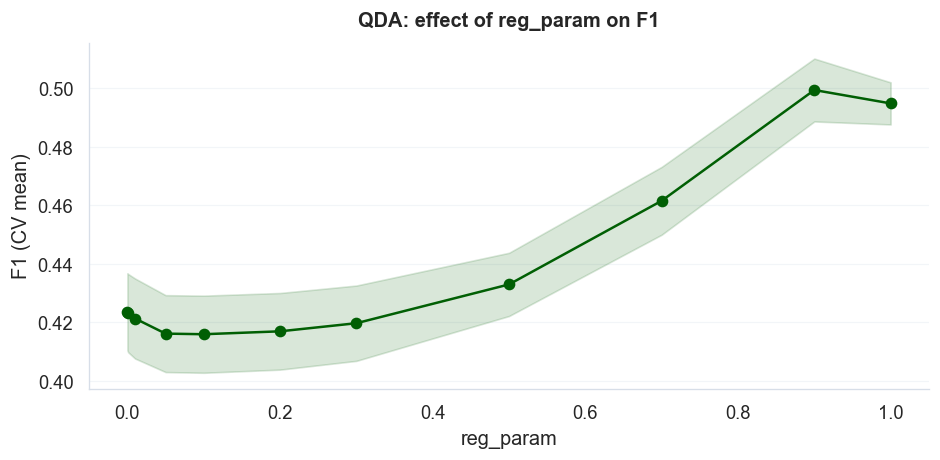

In [16]:
qda_cv_df = pd.DataFrame(qda_search.cv_results_)
qda_table = qda_cv_df[
    ["param_reg_param", "mean_test_score", "std_test_score"]
].copy()
qda_table.columns = ["reg_param", "F1_mean", "F1_std"]
qda_table = qda_table.sort_values("reg_param")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(qda_table["reg_param"], qda_table["F1_mean"], marker="o", color=MODEL_PALETTE["QDA"])
ax.fill_between(
    qda_table["reg_param"],
    qda_table["F1_mean"] - qda_table["F1_std"],
    qda_table["F1_mean"] + qda_table["F1_std"],
    alpha=0.15,
    color=MODEL_PALETTE["QDA"],
)
ax.set_xlabel("reg_param")
ax.set_ylabel("F1 (CV mean)")
ax.set_title("QDA: effect of reg_param on F1")
polish_axes(ax)
plt.tight_layout()
plt.show()

F1 increases monotonically with reg_param, peaking at 0.9 before dropping slightly at
1.0. This means QDA only performs well when it almost completely ignores the per-class
covariance structure and treats features as independent with equal variance. The raw
per-class covariance estimates are too noisy
to be useful, so the model benefits from shrinking them away almost entirely. At reg_param=0.9
QDA reaches F1=0.499, still well below LDA's 0.653 on the full matrix. The conclusion
is that the per-class covariance assumption does not hold on this data: the two income
groups do not differ meaningfully in their feature covariance structure, and LDA's
shared covariance is the better inductive bias.

### 4.5 LDA vs QDA: learned covariance structure

A direct comparison of the per-class covariance matrices estimated by QDA reveals whether the two income classes genuinely differ in their feature covariance structure. If the matrices are similar, LDA's pooled assumption is approximately correct and QDA's added flexibility is not useful.

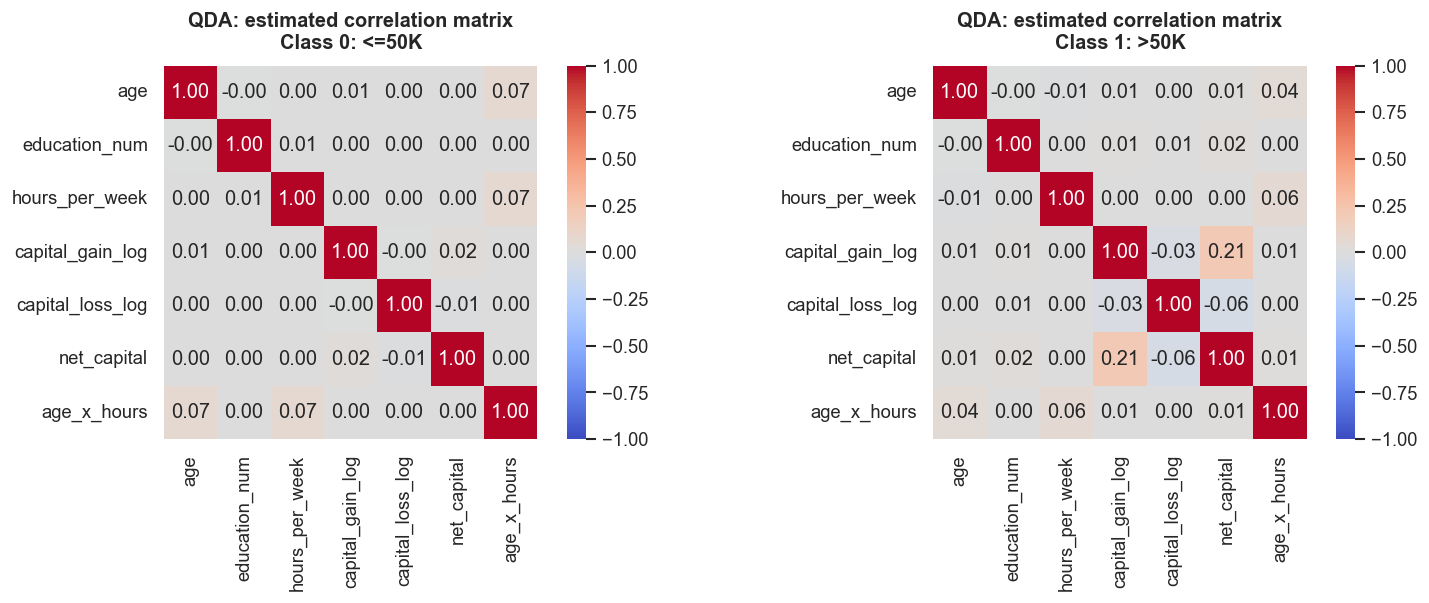

Frobenius norm of covariance difference (class 0 vs class 1): 0.5338


In [17]:
qda_best = QuadraticDiscriminantAnalysis(
    reg_param=qda_search.best_params_["reg_param"],
    store_covariance=True,
)
qda_best.fit(X_cont_train, y_train)

feat_labels = [f.replace("num__", "") for f in continuous_features]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (label, title) in enumerate([(0, "Class 0: <=50K"), (1, "Class 1: >50K")]):
    cov = qda_best.covariance_[i]
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        ax=axes[i],
        square=True,
        xticklabels=feat_labels,
        yticklabels=feat_labels,
    )
    axes[i].set_title(f"QDA: estimated correlation matrix\n{title}")

plt.tight_layout()
plt.show()

diff_norm = np.linalg.norm(qda_best.covariance_[0] - qda_best.covariance_[1], "fro")
print(f"Frobenius norm of covariance difference (class 0 vs class 1): {diff_norm:.4f}")

The two per-class correlation matrices are nearly identical and almost perfectly diagonal.
The off-diagonal structure is negligible in both classes, with the only non-trivial entry
being the correlation between capital_gain_log and net_capital in the >50K class (0.214),
which is expected since net_capital is partly derived from capital_gain. This confirms
the conclusion from the reg_param sweep: the two income classes do not differ in their
covariance structure, so QDA's added flexibility over LDA is not justified by the data.
The matrices also confirm why the EDA found no multicollinearity among the continuous
features: once conditioned on the class, the features are essentially independent.

### 4.6 Imbalance handling: prior adjustment

Both LDA and QDA expose a `priors` parameter that changes the $P(y)$ term used at
prediction time via Bayes' rule, which is mathematically equivalent to shifting the
decision threshold post-hoc rather than modifying the learned model. Given the poor
performance of QDA on this dataset, this analysis is carried out on the best LDA
configuration only.

In [18]:
lda_best_params = lda_search.best_params_.copy()

lda_empirical = LinearDiscriminantAnalysis(
    solver=lda_best_params["solver"],
    shrinkage=lda_best_params["shrinkage"],
)
lda_uniform = LinearDiscriminantAnalysis(
    solver=lda_best_params["solver"],
    shrinkage=lda_best_params["shrinkage"],
    priors=[0.5, 0.5],
)

s_empirical = cross_validate(lda_empirical, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
s_uniform = cross_validate(lda_uniform, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)

prior_comparison = pd.DataFrame(
    {
        "empirical priors": [s_empirical[f"test_{m}"].mean() for m in SCORING],
        "uniform priors [0.5, 0.5]": [s_uniform[f"test_{m}"].mean() for m in SCORING],
    },
    index=list(SCORING),
)
print(prior_comparison.round(4).to_string())

           empirical priors  uniform priors [0.5, 0.5]
f1                   0.6534                     0.6673
roc_auc              0.9002                     0.8986
aupr                 0.7532                     0.7412
accuracy             0.8467                     0.7942
precision            0.7174                     0.5463
recall               0.6000                     0.8572


Uniform priors improve F1 slightly (0.653 to 0.667) by aggressively predicting the
minority class more often: recall jumps from 0.600 to 0.857 at the cost of precision
dropping from 0.717 to 0.546. ROC-AUC and AUPR are essentially unchanged, confirming
that the underlying probability ranking is identical and only the decision threshold
has shifted. Accuracy drops from 0.847 to 0.794 because the model now misclassifies
more majority class samples. Whether empirical or uniform priors are preferable depends
on the application: if missing a high-income individual is more costly than a false
alarm, uniform priors are the better choice. For this project the empirical priors are
kept since F1 is the primary metric and the difference is small.

### 4.7 Best LDA and QDA models

In [19]:
for name, model, feats in [
    ("LDA", lda_best, list(X_train.columns)),
    ("QDA", qda_best, continuous_features),
]:
    scores = cross_validate(
        model, X_train[feats], y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )
    record_cv(name, scores)

pd.DataFrame(results).set_index("model").round(3)

,f1_mean,f1_std,roc_auc_mean,roc_auc_std,aupr_mean,aupr_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
model,,,,,,,,,,,,
Baseline: Dummy (most_frequent),0.000,0.000,0.500,0.000,0.241,0.000,0.759,0.000,0.000,0.000,0.000,0.000
LDA,0.653,0.008,0.900,0.002,0.753,0.008,0.847,0.005,0.717,0.015,0.600,0.006
QDA,0.499,0.011,0.823,0.004,0.625,0.009,0.797,0.004,0.615,0.011,0.421,0.011


LDA and QDA represent opposite ends of the RDA spectrum in terms of covariance
flexibility, and the results reflect this clearly. LDA, trained on the full 73-feature
matrix with shrinkage=0.2, reaches F1=0.653 and ROC-AUC=0.900. QDA, which can only
be trained on the 7 continuous features due to the dimensionality of its per-class
covariance estimation, reaches F1=0.499 and ROC-AUC=0.823.

The shrinkage analysis for LDA showed that mild regularization around 0.2 is optimal,
enough to stabilize the covariance estimates given the noisy capital features but not
so much that the genuine class-specific structure from the categorical variables is
lost. For QDA the picture is the opposite, as performance improves monotonically toward
reg_param=0.9, meaning the model only becomes useful when it nearly abandons its own
per-class covariance estimates. The covariance heatmaps confirm why: the two income
classes have almost identical feature covariance structure on the continuous features,
so the extra parameters QDA estimates per class are noise rather than signal.

The feature importance analysis via LD1 loadings showed that marital status, executive
and professional occupations, relationship categories and net capital drive the
separation most, fully consistent with the EDA findings. Features with near-zero
loadings were identified but keeping the full matrix proved better than dropping them,
since LDA with shrinkage already handles redundant features implicitly.

Overall, the shared covariance assumption of LDA is not just a simplification on this
dataset but the right modelling choice. LDA is selected as the finalist from this family.

## 5. Naive Bayes

Naive Bayes also models the class-conditional densities and applies Bayes' rule, but
with the strong assumption that the features are conditionally independent given the class:

$$P(x \mid y = k) = \prod_{j=1}^{p} P(x_j \mid y = k)$$

This makes it a special case of discriminant analysis where the covariance matrix is
forced to be diagonal. The degree to which this assumption holds varies by feature type.
For the continuous features, the EDA numerical correlation matrix showed very low
pairwise correlations, meaning the independence assumption is approximately satisfied.
For the categorical features the picture is different: the Cramer's V analysis found
strong associations between sex, relationship and marital_status, and between occupation
and sex.

Three variants are evaluated:

- **GaussianNB** on the continuous features: the cleanest application of the Gaussian assumption.
- **BernoulliNB** on the binary and one-hot features: the correct distributional family for 0/1 columns.
- **CombinedNB** (Gaussian x Bernoulli): the principled approach for mixed data, where each block uses its appropriate distribution.

In [20]:
gnb_param_grid = {"var_smoothing": np.logspace(-12, -1, 12)}

gnb_search = GridSearchCV(
    GaussianNB(),
    param_grid=gnb_param_grid,
    scoring=PRIMARY_METRIC,
    cv=cv,
    n_jobs=-1,
    refit=True,
)
gnb_search.fit(X_cont_train, y_train)

print(f"Best F1 (CV): {gnb_search.best_score_:.4f}")
print(f"Best params:  {gnb_search.best_params_}")

Best F1 (CV): 0.4155
Best params:  {'var_smoothing': np.float64(0.1)}


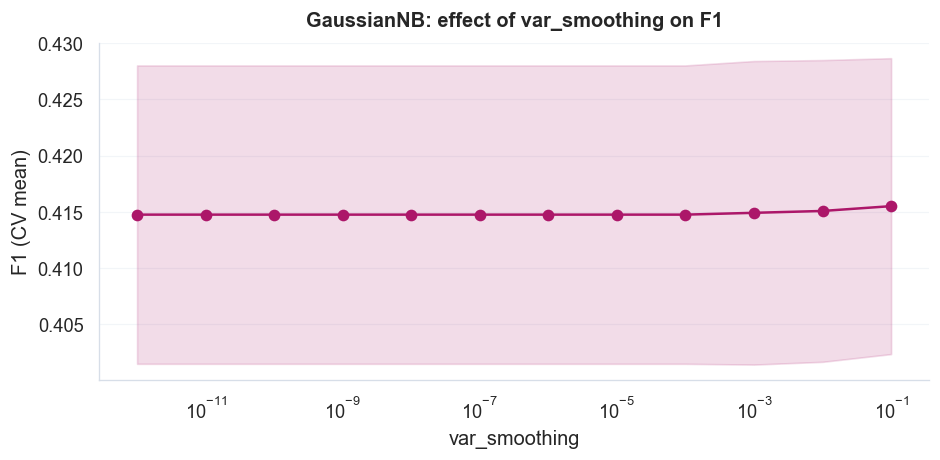

In [21]:
gnb_cv_df = pd.DataFrame(gnb_search.cv_results_)
gnb_cv_df = gnb_cv_df.sort_values("param_var_smoothing")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gnb_cv_df["param_var_smoothing"], gnb_cv_df["mean_test_score"],
        marker="o", color=MODEL_PALETTE["GaussianNB"])
ax.fill_between(
    gnb_cv_df["param_var_smoothing"],
    gnb_cv_df["mean_test_score"] - gnb_cv_df["std_test_score"],
    gnb_cv_df["mean_test_score"] + gnb_cv_df["std_test_score"],
    alpha=0.15,
    color=MODEL_PALETTE["GaussianNB"],
)
ax.set_xscale("log")
ax.set_xlabel("var_smoothing")
ax.set_ylabel("F1 (CV mean)")
ax.set_title("GaussianNB: effect of var_smoothing on F1")
polish_axes(ax)
plt.tight_layout()
plt.show()

The var_smoothing parameter has virtually no effect on performance: F1 stays flat at 0.415 across
the entire range tested. GaussianNB on the continuous features alone is a weak model,
consistent with what the Gaussian assumption check showed: the capital features are
heavily zero-inflated and their within-class distributions are far from Gaussian, so
the likelihood estimates are poor regardless of smoothing. The default value is kept.

### 5.2 Bernoulli Naive Bayes (binary and one-hot features)

`BernoulliNB` models each feature as a Bernoulli distribution given the class, estimating $\theta_{jk} = P(x_j = 1 \mid y = k)$ for each feature $j$ and class $k$. Laplace smoothing controlled by `alpha` handles features that never appear in one of the classes.

In [22]:
X_bin_train = X_train[binary_block].copy()
X_bin_test = X_test[binary_block].copy()

bnb_param_grid = {"alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}

bnb_search = GridSearchCV(
    BernoulliNB(),
    param_grid=bnb_param_grid,
    scoring=PRIMARY_METRIC,
    cv=cv,
    n_jobs=-1,
    refit=True,
)
bnb_search.fit(X_bin_train, y_train)

print(f"Best F1 (CV): {bnb_search.best_score_:.4f}")
print(f"Best params:  {bnb_search.best_params_}")

Best F1 (CV): 0.6516
Best params:  {'alpha': 5.0}


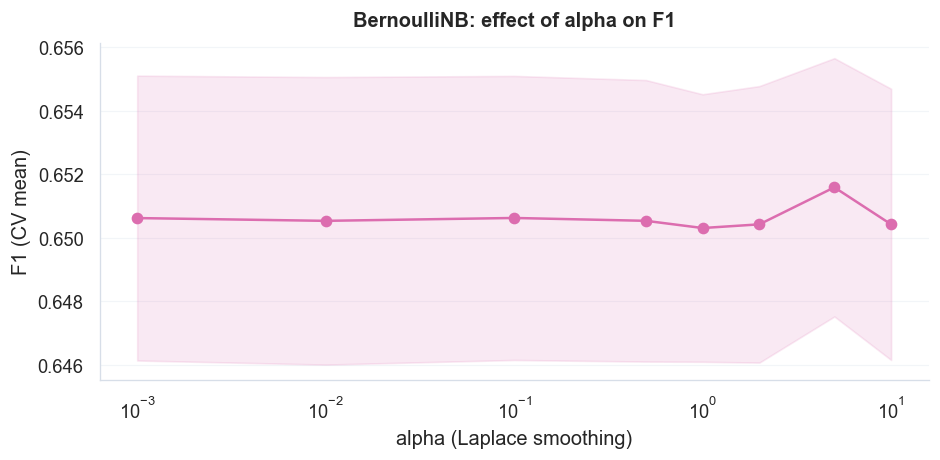

In [23]:
bnb_cv_df = pd.DataFrame(bnb_search.cv_results_)
bnb_cv_df = bnb_cv_df.sort_values("param_alpha")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bnb_cv_df["param_alpha"], bnb_cv_df["mean_test_score"],
        marker="o", color=MODEL_PALETTE["BernoulliNB"])
ax.fill_between(
    bnb_cv_df["param_alpha"],
    bnb_cv_df["mean_test_score"] - bnb_cv_df["std_test_score"],
    bnb_cv_df["mean_test_score"] + bnb_cv_df["std_test_score"],
    alpha=0.15,
    color=MODEL_PALETTE["BernoulliNB"],
)
ax.set_xscale("log")
ax.set_xlabel("alpha (Laplace smoothing)")
ax.set_ylabel("F1 (CV mean)")
ax.set_title("BernoulliNB: effect of alpha on F1")
polish_axes(ax)
plt.tight_layout()
plt.show()

The alpha has virtually no effect on performance: F1 stays flat around 0.650 across the
entire range from 0.001 to 10. This means the Laplace smoothing amount does not matter
here, likely because the dataset is large enough that near-zero probability estimates
are not an issue for any of the binary/one-hot features. The default value of 1.0 is kept.

#### 5.2.1 BernoulliNB: most discriminative features

The log-ratio $\log P(x_j = 1 \mid y = 1) - \log P(x_j = 1 \mid y = 0)$ serves as a natural feature importance score: large positive values indicate features strongly associated with the >50K class, large negative values indicate features strongly associated with <=50K.

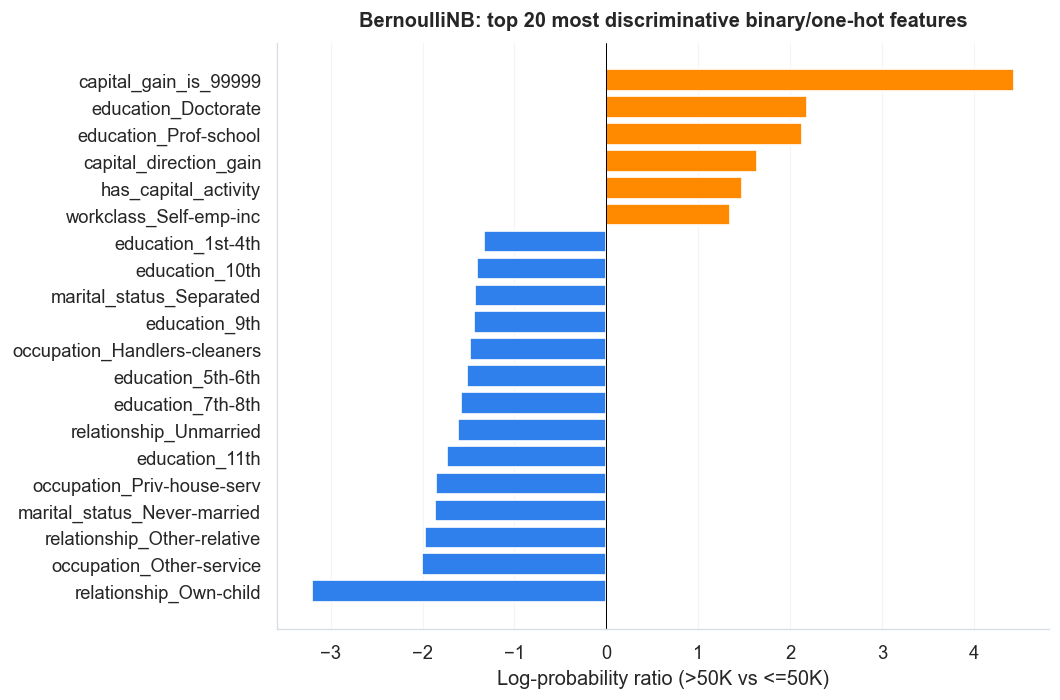

In [24]:
bnb_best = bnb_search.best_estimator_

log_ratio = bnb_best.feature_log_prob_[1] - bnb_best.feature_log_prob_[0]
importance_df = pd.DataFrame(
    {"feature": binary_block, "log_ratio": log_ratio}
).sort_values("log_ratio", key=abs, ascending=False)

top_n = 20
top = importance_df.head(top_n).sort_values("log_ratio")

fig, ax = plt.subplots(figsize=(9, 6))
colors = [
    PLOT_COLORS["income_high"] if v > 0 else PLOT_COLORS["income_low"]
    for v in top["log_ratio"]
]
ax.barh(
    top["feature"].str.replace("bin__", "").str.replace("cat__", ""),
    top["log_ratio"],
    color=colors,
)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Log-probability ratio (>50K vs <=50K)")
ax.set_title(f"BernoulliNB: top {top_n} most discriminative binary/one-hot features")
polish_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

The most discriminative binary feature by far is capital_gain_is_99999, with a
log-ratio of 4.43, meaning individuals with that flag are overwhelmingly more likely
to earn above 50K. This is consistent with the EDA finding that the 99999 capital gain
value was a special encoding associated with high income. has_capital_activity also
appears in the top 20 with a positive ratio, reinforcing that any capital activity at
all is a strong income signal.

On the education side, Doctorate and Prof-school have the strongest positive loadings
among education categories, while primary and lower secondary levels (1st-4th, 5th-6th,
7th-8th, 9th, 10th, 11th) dominate the negative side. The relationship and marital
status categories follow the same pattern seen in the LDA loadings: Own-child,
Unmarried, Never-married and Separated are strongly associated with low income, while
the positive side is represented by capital direction and high-skill workclass categories.

Compared to the LDA loadings, BernoulliNB places much more weight on the rare
extreme categories (very low education levels, specific occupations like Priv-house-serv
and Handlers-cleaners) because it models each dummy independently without borrowing
strength across related categories the way LDA does through the covariance structure.

### 5.3 Combined Naive Bayes (Gaussian x Bernoulli)

The combined model trains a GaussianNB on the continuous block and a BernoulliNB on the binary/one-hot block, then multiplies their predicted probabilities and renormalizes. Under the conditional independence assumption this gives the exact posterior, with each feature block modelled by the appropriate distribution.

The class prior $P(y)$ is present in both component models, so a naive product would count it twice. Dividing out one copy before renormalizing corrects this.

In [25]:
   
class CombinedNB(ClassifierMixin, BaseEstimator):
    """GaussianNB on continuous features combined with BernoulliNB on binary/one-hot features."""

    _estimator_type = "classifier"

    def __init__(self, continuous_cols=None, binary_cols=None, var_smoothing=1e-9, alpha=1.0):
        self.continuous_cols = continuous_cols
        self.binary_cols = binary_cols
        self.var_smoothing = var_smoothing
        self.alpha = alpha

    def fit(self, X, y):
        X = pd.DataFrame(X, columns=getattr(X, "columns", None)) if not isinstance(X, pd.DataFrame) else X
        self.gnb_ = GaussianNB(var_smoothing=self.var_smoothing)
        self.bnb_ = BernoulliNB(alpha=self.alpha)
        self.gnb_.fit(X[self.continuous_cols], y)
        self.bnb_.fit(X[self.binary_cols], y)
        self.classes_ = self.gnb_.classes_
        self.class_prior_ = np.bincount(y) / len(y)
        return self

    def predict_proba(self, X):
        X = pd.DataFrame(X, columns=getattr(X, "columns", None)) if not isinstance(X, pd.DataFrame) else X
        log_p_cont = np.log(self.gnb_.predict_proba(X[self.continuous_cols]) + 1e-300)
        log_p_bin = np.log(self.bnb_.predict_proba(X[self.binary_cols]) + 1e-300)
        log_prior = np.log(self.class_prior_ + 1e-300)
        log_joint = log_p_cont + log_p_bin - log_prior
        log_joint -= log_joint.max(axis=1, keepdims=True)
        joint = np.exp(log_joint)
        return joint / joint.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

In [26]:
combined_param_grid = {
    "var_smoothing": np.logspace(-12, -1, 6),
    "alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
}

combined_search = GridSearchCV(
    CombinedNB(continuous_cols=continuous_features, binary_cols=binary_block),
    param_grid=combined_param_grid,
    scoring=PRIMARY_METRIC,
    cv=cv,
    n_jobs=-1,
    refit=True,
)
combined_search.fit(X_train, y_train)

print(f"Best F1 (CV): {combined_search.best_score_:.4f}")
print(f"Best params:  {combined_search.best_params_}")

Best F1 (CV): 0.6182
Best params:  {'alpha': 0.01, 'var_smoothing': np.float64(0.1)}


The combined model reaches F1=0.618, which falls between GaussianNB (0.415) and
BernoulliNB (0.651). Adding the continuous block on top of the binary/one-hot block
does not improve over BernoulliNB alone. This is somewhat surprising but explainable:
the continuous features are heavily non-Gaussian, so the GaussianNB component produces
poor likelihood estimates that add noise rather than signal when multiplied with the
well-calibrated BernoulliNB probabilities. The best hyperparameters reflect this too,
with var_smoothing=0.1 being relatively high, indicating the Gaussian component needs
heavy smoothing to avoid its noisy estimates dominating the combined posterior.

### 5.5 Ablation: Gaussian only vs Bernoulli only vs Combined

This ablation shows the marginal contribution of each feature block. If GaussianNB on continuous features already captures most of the signal, the combined model should still improve but modestly. If BernoulliNB on the categorical block outperforms GaussianNB alone, it would suggest that occupation, education and marital status carry more signal than age, hours and capital activity.

In [27]:
gnb_best = gnb_search.best_estimator_
combined_best = combined_search.best_estimator_

ablation_rows = []
for name, model, feats in [
    ("GaussianNB (continuous only)", gnb_best, continuous_features),
    ("BernoulliNB (binary + one-hot only)", bnb_best, binary_block),
    ("CombinedNB (Gaussian x Bernoulli)", combined_best, list(X_train.columns)),
]:
    scores = cross_validate(
        model, X_train[feats], y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )
    ablation_rows.append({
        "model": name,
        "F1_mean": round(scores["test_f1"].mean(), 4),
        "F1_std": round(scores["test_f1"].std(), 4),
        "ROC_AUC_mean": round(scores["test_roc_auc"].mean(), 4),
        "AUPR_mean": round(scores["test_aupr"].mean(), 4),
    })

ablation_df = pd.DataFrame(ablation_rows).set_index("model")
print(ablation_df.to_string())

                                     F1_mean  F1_std  ROC_AUC_mean  AUPR_mean
model                                                                        
GaussianNB (continuous only)          0.4155  0.0132        0.8226     0.6257
BernoulliNB (binary + one-hot only)   0.6516  0.0041        0.8804     0.7016
CombinedNB (Gaussian x Bernoulli)     0.6182  0.0100        0.8815     0.7039


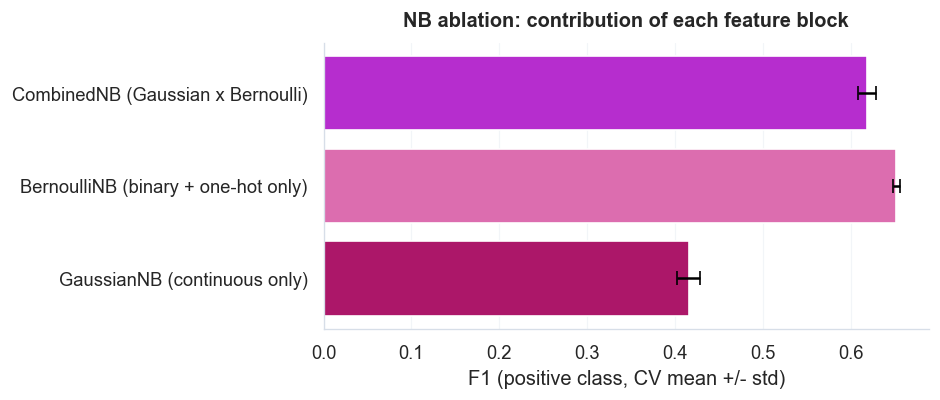

In [28]:
fig, ax = plt.subplots(figsize=(8, 3.5))
y_pos = np.arange(len(ablation_df))
colors_bar = [
    MODEL_PALETTE["GaussianNB"],
    MODEL_PALETTE["BernoulliNB"],
    MODEL_PALETTE["CombinedNB"],
]
ax.barh(
    y_pos,
    ablation_df["F1_mean"],
    xerr=ablation_df["F1_std"],
    color=colors_bar,
    capsize=4,
    edgecolor="white",
)
ax.set_yticks(y_pos)
ax.set_yticklabels(ablation_df.index)
ax.set_xlabel("F1 (positive class, CV mean +/- std)")
ax.set_title("NB ablation: contribution of each feature block")
polish_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

The ablation confirms that the binary and one-hot block drives almost all the
discriminative signal in this dataset. BernoulliNB on categorical features alone
reaches F1=0.652 and ROC-AUC=0.880, while GaussianNB on continuous features only
reaches F1=0.415 despite having a surprisingly good ROC-AUC of 0.823, meaning it
ranks samples reasonably well but struggles to calibrate the decision boundary.

The combined model reaches F1=0.618, ROC-AUC=0.882 and AUPR=0.704, marginally
outperforming BernoulliNB on ROC-AUC and AUPR but underperforming on F1. This means
the continuous block does add ranking information when the two components are combined,
but the poor Gaussian likelihood estimates hurt the decision boundary enough to lower
F1. The categorical features are what drive income prediction in this dataset: education,
occupation, marital status and relationship status encode the signal far more cleanly
than age, hours or capital activity through a Gaussian likelihood.

### 5.6 Record NB finalists

In [29]:
for name, model, feats in [
    ("NB Gaussian", gnb_best, continuous_features),
    ("NB Bernoulli", bnb_best, binary_block),
    ("NB Combined (Gaussian x Bernoulli)", combined_best, list(X_train.columns)),
]:
    scores = cross_validate(
        model, X_train[feats], y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )
    record_cv(name, scores)

nb_names = ["NB Gaussian", "NB Bernoulli", "NB Combined (Gaussian x Bernoulli)"]
pd.DataFrame([r for r in results if r["model"] in nb_names]).set_index("model").round(3)

,f1_mean,f1_std,roc_auc_mean,roc_auc_std,aupr_mean,aupr_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
model,,,,,,,,,,,,
NB Gaussian,0.416,0.013,0.823,0.005,0.626,0.010,0.783,0.004,0.592,0.012,0.320,0.012
NB Bernoulli,0.652,0.004,0.880,0.002,0.702,0.004,0.809,0.003,0.581,0.005,0.741,0.004
NB Combined (Gaussian x Bernoulli),0.618,0.010,0.882,0.001,0.704,0.009,0.821,0.005,0.634,0.010,0.603,0.011


The three Naive Bayes variants tell a coherent story about where the income signal lives
in this dataset. GaussianNB on the continuous features alone reaches F1=0.416, a weak
result consistent with the Gaussian assumption check: the capital features are
zero-inflated and their likelihood estimates are unreliable regardless of smoothing.
Its ROC-AUC of 0.823 is notably higher than its F1 suggests, meaning it ranks samples
reasonably well in relative terms but cannot find a good decision boundary.

BernoulliNB on the categorical block alone reaches F1=0.652 with very low variance
(std=0.004), making it the most stable model in the family and competitive with LDA.
The low variance reflects the large number of training samples per category and the
robustness of Bernoulli likelihoods to the independence violations identified in the
Cramer's V analysis. Recall is particularly high at 0.741, meaning BernoulliNB is
aggressive in predicting the minority class, which is consistent with the strong
log-probability ratios found for education, marital status and relationship categories.

The combined model improves ROC-AUC (0.882) and AUPR (0.704) over BernoulliNB alone,
confirming that the continuous block does add ranking information. However F1 drops to
0.618 because the noisy Gaussian likelihoods shift the decision boundary. Precision
rises to 0.634 while recall drops to 0.603 compared to BernoulliNB, meaning the
combined model is more conservative in predicting the minority class.

BernoulliNB is selected as the finalist from the Naive Bayes family based on the
highest F1 and lowest variance.

## 6. Cross-family comparison

All finalists are compared on the same cross-validation folds. The comparison is paired: every model sees exactly the same training and validation rows in every fold, so differences in mean score reflect differences in the model, not in the data partition.

### 6.1 CV scores table

In [30]:
results_df = pd.DataFrame(results).set_index("model")
metric_order = ["f1", "roc_auc", "aupr", "accuracy", "precision", "recall"]
ordered_cols = [f"{m}_mean" for m in metric_order] + [f"{m}_std" for m in metric_order]
results_df = results_df[ordered_cols]
results_df.round(4).sort_values("f1_mean", ascending=False)

,f1_mean,roc_auc_mean,aupr_mean,accuracy_mean,precision_mean,recall_mean,f1_std,roc_auc_std,aupr_std,accuracy_std,precision_std,recall_std
model,,,,,,,,,,,,
LDA,0.6534,0.9002,0.7532,0.8467,0.7174,0.6000,0.0083,0.0019,0.0076,0.0046,0.0155,0.0057
NB Bernoulli,0.6516,0.8804,0.7016,0.8091,0.5814,0.7411,0.0041,0.0018,0.0035,0.0029,0.0054,0.0041
NB Combined (Gaussian x Bernoulli),0.6182,0.8815,0.7039,0.8206,0.6341,0.6031,0.0100,0.0008,0.0094,0.0046,0.0101,0.0108
QDA,0.4994,0.8228,0.6247,0.7970,0.6146,0.4207,0.0108,0.0043,0.0093,0.0038,0.0115,0.0110
NB Gaussian,0.4155,0.8226,0.6257,0.7832,0.5922,0.3201,0.0132,0.0046,0.0100,0.0035,0.0121,0.0124
Baseline: Dummy (most_frequent),0.0000,0.5000,0.2408,0.7592,0.0000,0.0000,0.0000,0.0000,0.0001,0.0001,0.0000,0.0000


### 6.2 F1 comparison plot

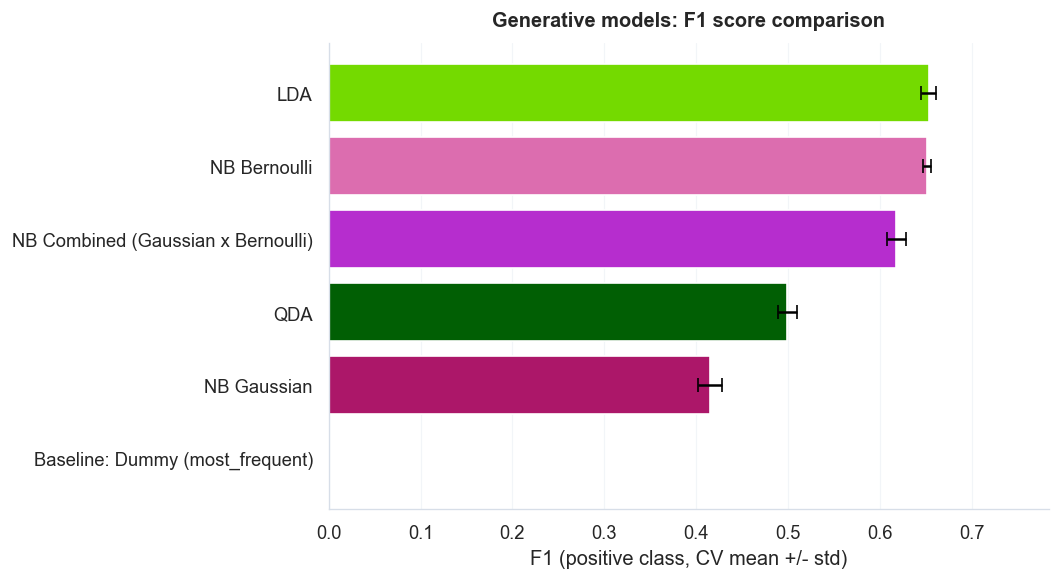

In [31]:
sorted_results = results_df.sort_values("f1_mean")

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(sorted_results))

bar_colors = []
for name in sorted_results.index:
    if "Baseline" in name:
        bar_colors.append(MODEL_PALETTE["Baseline"])
    elif "LDA" in name:
        bar_colors.append(MODEL_PALETTE["LDA"])
    elif "QDA" in name:
        bar_colors.append(MODEL_PALETTE["QDA"])
    elif "Combined" in name:
        bar_colors.append(MODEL_PALETTE["CombinedNB"])
    elif "Gaussian" in name:
        bar_colors.append(MODEL_PALETTE["GaussianNB"])
    elif "Bernoulli" in name:
        bar_colors.append(MODEL_PALETTE["BernoulliNB"])
    else:
        bar_colors.append(PLOT_COLORS["neutral"])

ax.barh(
    y_pos,
    sorted_results["f1_mean"],
    xerr=sorted_results["f1_std"],
    color=bar_colors,
    capsize=4,
    edgecolor="white",
)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_results.index)
ax.set_xlabel("F1 (positive class, CV mean +/- std)")
ax.set_title("Generative models: F1 score comparison")
ax.set_xlim(0, max(sorted_results["f1_mean"]) * 1.2)
polish_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

### 6.3 ROC and Precision-Recall curves

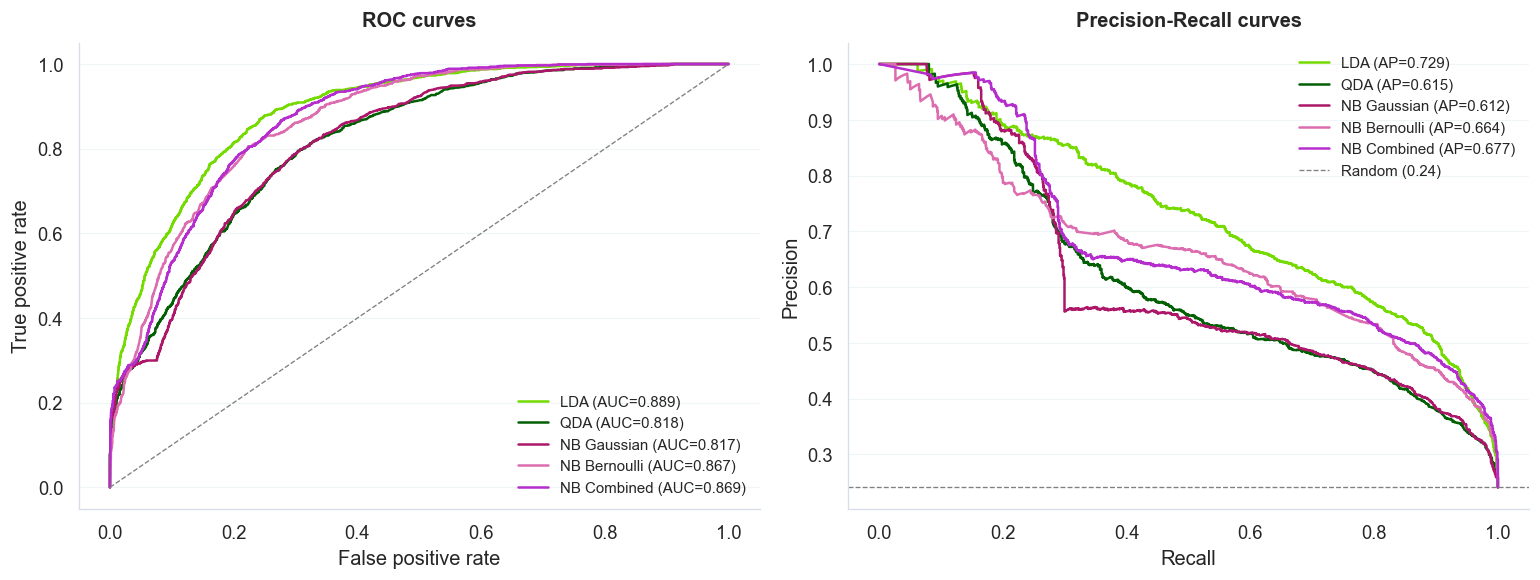

In [32]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

finalists = {
    "LDA": (lda_best, list(X_train.columns)),
    "QDA": (qda_best, continuous_features),
    "NB Gaussian": (gnb_best, continuous_features),
    "NB Bernoulli": (bnb_best, binary_block),
    "NB Combined": (combined_best, list(X_train.columns)),
}

finalist_colors = {
    "LDA": MODEL_PALETTE["LDA"],
    "QDA": MODEL_PALETTE["QDA"],
    "NB Gaussian": MODEL_PALETTE["GaussianNB"],
    "NB Bernoulli": MODEL_PALETTE["BernoulliNB"],
    "NB Combined": MODEL_PALETTE["CombinedNB"],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (model, feats) in finalists.items():
    model.fit(X_tr[feats], y_tr)
    y_score = model.predict_proba(X_val[feats])[:, 1]
    color = finalist_colors[name]

    fpr, tpr, _ = roc_curve(y_val, y_score)
    auc = roc_auc_score(y_val, y_score)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)

    prec, rec, _ = precision_recall_curve(y_val, y_score)
    ap = average_precision_score(y_val, y_score)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves")
axes[0].legend(loc="lower right", fontsize=9)
polish_axes(axes[0])

axes[1].axhline(
    y_val.mean(), color="gray", linestyle="--", linewidth=0.8,
    label=f"Random ({y_val.mean():.2f})"
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend(loc="upper right", fontsize=9)
polish_axes(axes[1])

plt.tight_layout()
plt.show()

### 6.4 Model selection

In [33]:
non_baseline = results_df[~results_df.index.str.startswith("Baseline")]
best_model_name = non_baseline.sort_values(
    ["f1_mean", "aupr_mean"], ascending=False
).index[0]

print(f"Selected model: {best_model_name}")
print(f"  CV F1: {non_baseline.loc[best_model_name, 'f1_mean']:.4f} +/- {non_baseline.loc[best_model_name, 'f1_std']:.4f}")
print(f"  CV ROC-AUC: {non_baseline.loc[best_model_name, 'roc_auc_mean']:.4f}")
print(f"  CV AUPR: {non_baseline.loc[best_model_name, 'aupr_mean']:.4f}")

model_registry = {
    "LDA": (lda_best, list(X_train.columns)),
    "QDA": (qda_best, continuous_features),
    "NB Gaussian": (gnb_best, continuous_features),
    "NB Bernoulli": (bnb_best, binary_block),
    "NB Combined (Gaussian x Bernoulli)": (combined_best, list(X_train.columns)),
}

selected_model, selected_features = model_registry[best_model_name]

Selected model: LDA
  CV F1: 0.6534 +/- 0.0083
  CV ROC-AUC: 0.9002
  CV AUPR: 0.7532


In [34]:
results_df = pd.DataFrame(results).set_index("model")
metric_order = ["f1", "roc_auc", "aupr", "accuracy", "precision", "recall"]
ordered_cols = [f"{m}_mean" for m in metric_order] + [f"{m}_std" for m in metric_order]
results_df = results_df[ordered_cols]
results_df.round(4).sort_values("f1_mean", ascending=False)

,f1_mean,roc_auc_mean,aupr_mean,accuracy_mean,precision_mean,recall_mean,f1_std,roc_auc_std,aupr_std,accuracy_std,precision_std,recall_std
model,,,,,,,,,,,,
LDA,0.6534,0.9002,0.7532,0.8467,0.7174,0.6000,0.0083,0.0019,0.0076,0.0046,0.0155,0.0057
NB Bernoulli,0.6516,0.8804,0.7016,0.8091,0.5814,0.7411,0.0041,0.0018,0.0035,0.0029,0.0054,0.0041
NB Combined (Gaussian x Bernoulli),0.6182,0.8815,0.7039,0.8206,0.6341,0.6031,0.0100,0.0008,0.0094,0.0046,0.0101,0.0108
QDA,0.4994,0.8228,0.6247,0.7970,0.6146,0.4207,0.0108,0.0043,0.0093,0.0038,0.0115,0.0110
NB Gaussian,0.4155,0.8226,0.6257,0.7832,0.5922,0.3201,0.0132,0.0046,0.0100,0.0035,0.0121,0.0124
Baseline: Dummy (most_frequent),0.0000,0.5000,0.2408,0.7592,0.0000,0.0000,0.0000,0.0000,0.0001,0.0001,0.0000,0.0000


LDA is the best model overall, leading on F1 (0.653), ROC-AUC (0.900) and AUPR (0.753)
with low variance across all metrics. The ROC and PR curves confirm this visually: LDA
sits clearly above all other models across the full range of thresholds, with a
particularly large gap in the PR curve at mid-to-high recall values where the other
models degrade faster.

BernoulliNB is the closest competitor with F1=0.652, essentially matching LDA on that
metric, but the gap is larger on ROC-AUC (0.880) and AUPR (0.702). The PR curve shows
that BernoulliNB trades precision for recall more aggressively than LDA, which explains
the similar F1 despite the lower AUPR. Its very low variance makes it the most stable
model in the comparison.

The combined NB improves over BernoulliNB on ROC-AUC (0.882) and AUPR (0.704) but
drops on F1 (0.618), confirming that the continuous block adds ranking information but
hurts the decision boundary. The PR curves of BernoulliNB and NB Combined are nearly
identical, diverging only at high recall.

QDA and GaussianNB perform similarly on ROC-AUC (0.823 and 0.823) and AUPR (0.625 and
0.626) despite using different feature sets and distributional assumptions, suggesting
they are capturing a similar amount of signal. Both fall well below LDA and BernoulliNB
on F1, confirming that neither the per-class Gaussian on continuous features nor the
shared Gaussian on continuous features alone is sufficient for this classification task.

LDA is selected as the best overall model. Its advantage over BernoulliNB on the
ranking metrics (ROC-AUC and AUPR) indicates that the continuous features do contribute
meaningful signal when handled through a properly regularized shared covariance
structure, something neither the Gaussian nor the combined NB could achieve.

## 7. Final test set evaluation

The selected model is refit on the full training set and evaluated on the held-out test set. This is the only point in the notebook where the test set is used.

In [35]:
selected_model.fit(X_train[selected_features], y_train)

y_pred = selected_model.predict(X_test[selected_features])
y_score = selected_model.predict_proba(X_test[selected_features])[:, 1]

test_metrics = {
    "F1 (positive)": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_score),
    "AUPR": average_precision_score(y_test, y_score),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
}

print(f"Final model: {best_model_name}")
print()
print("Test set performance:")
for name, value in test_metrics.items():
    print(f"  {name:18s} {value:.4f}")

Final model: LDA

Test set performance:
  F1 (positive)      0.6565
  ROC-AUC            0.8987
  AUPR               0.7576
  Accuracy           0.8475
  Precision          0.7173
  Recall             0.6052


### 7.1 Confusion matrix

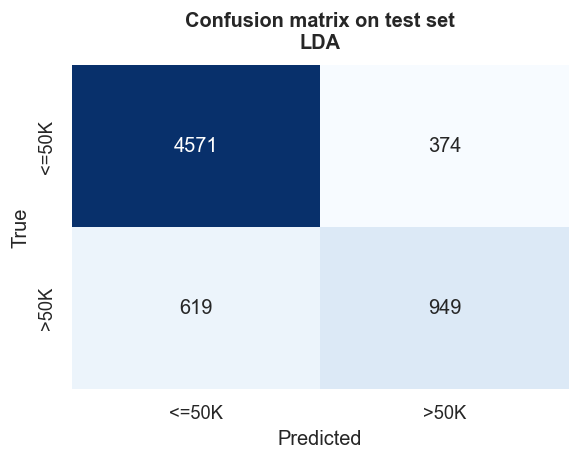

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4945
        >50K       0.72      0.61      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.76      0.78      6513
weighted avg       0.84      0.85      0.84      6513



In [36]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix on test set\n{best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

### 7.2 CV vs test comparison

In [37]:
cv_vs_test = pd.DataFrame(
    {
        "CV mean": [
            non_baseline.loc[best_model_name, "f1_mean"],
            non_baseline.loc[best_model_name, "roc_auc_mean"],
            non_baseline.loc[best_model_name, "aupr_mean"],
            non_baseline.loc[best_model_name, "accuracy_mean"],
        ],
        "Test": [
            test_metrics["F1 (positive)"],
            test_metrics["ROC-AUC"],
            test_metrics["AUPR"],
            test_metrics["Accuracy"],
        ],
    },
    index=["F1", "ROC-AUC", "AUPR", "Accuracy"],
)
cv_vs_test["delta"] = (cv_vs_test["Test"] - cv_vs_test["CV mean"]).round(4)
print(cv_vs_test.round(4).to_string())

          CV mean    Test   delta
F1         0.6534  0.6565  0.0031
ROC-AUC    0.9002  0.8987 -0.0015
AUPR       0.7532  0.7576  0.0044
Accuracy   0.8467  0.8475  0.0009


The test set results are almost identical to the cross-validated estimates across all
metrics, with deltas below 0.005 in absolute value. This confirms that the
cross-validation protocol gave a reliable and unbiased picture of generalization: the
model did not overfit the training data and the 5-fold stratified setup was sufficient
to estimate performance accurately.

On the test set LDA reaches F1=0.657, ROC-AUC=0.899 and AUPR=0.758. The confusion
matrix and classification report show the typical pattern for a model trained on
imbalanced data: the majority class (<=50K) is predicted with high precision and recall
(0.88 and 0.92), while the minority class (>50K) shows lower precision (0.72) and
recall (0.61). The model is more conservative on the minority class, missing around
39% of true high-income individuals.

The performance ceiling is set by the limited separability of the two income groups,
which the EDA and unsupervised analysis already identified. Even the strongest
individual predictors show moderate effect sizes, and the LD1 projection showed
substantial overlap between the two classes along the optimal linear direction.
Surpassing this ceiling requires non-linear methods that can capture the interaction
structure between features, which is addressed in the subsequent notebooks.